#🏦 Bank Marketing Campaign Optimizer

In [75]:
# Install required packages
!pip install ucimlrepo plotly scikit-learn xgboost imbalanced-learn -q

# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import warnings
warnings.filterwarnings('ignore')

#ML
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (classification_report, confusion_matrix, roc_auc_score,
                             roc_curve, precision_recall_curve, f1_score, accuracy_score)
from imblearn.over_sampling import SMOTE

# Styling
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [76]:
# ============================================================================
# LOAD DATASET FROM UPLOADED FILE
# ============================================================================

import pandas as pd
import numpy as np
from google.colab import files
import os


# Check if the file already exists (e.g., from a previous upload or mounted drive)
file_path = '/content/bank-additional-full.csv'
if not os.path.exists(file_path):
    print("⚠️ File not found at default path. Please upload 'bank-additional-full.csv'.")
    uploaded = files.upload()
    if 'bank-additional-full.csv' in uploaded:
        with open(file_path, 'wb') as f:
            f.write(uploaded['bank-additional-full.csv'])
        print("✅ File uploaded successfully to /content/")
    else:
        print("❌ Upload failed or incorrect file name. Please ensure you upload 'bank-additional-full.csv'.")
        # Handle the case where the file was not uploaded or wrong file was uploaded
        raise FileNotFoundError(f"Expected file 'bank-additional-full.csv' not found after upload attempt.")

# Load from uploaded file
df = pd.read_csv(file_path, sep=';')

print(f"✅ Dataset loaded successfully!")
print(f"📊 Shape: {df.shape}")
print(f"📊 Rows: {df.shape[0]:,}")
print(f"📊 Columns: {df.shape[1]}")

# Separate features and target
y = df['y']
X = df.drop('y', axis=1)

print(f"\n📋 All {len(df.columns)} columns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")

# Verify economic features
print(f"\n Checking economic features:")
economic_features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

for feature in economic_features:
    if feature in df.columns:
        print(f"  ✅ {feature}")
    else:
        print(f"  ❌ {feature} - MISSING")

print(f"\n Target Variable Distribution:")
print(df['y'].value_counts())
print(f"\n   Success Rate: {(df['y']=='yes').sum() / len(df) * 100:.2f}%")
print(f"   Class Imbalance Ratio: 1:{(df['y']=='no').sum() / (df['y']=='yes').sum():.1f}")




✅ Dataset loaded successfully!
📊 Shape: (41188, 21)
📊 Rows: 41,188
📊 Columns: 21

📋 All 21 columns:
   1. age
   2. job
   3. marital
   4. education
   5. default
   6. housing
   7. loan
   8. contact
   9. month
  10. day_of_week
  11. duration
  12. campaign
  13. pdays
  14. previous
  15. poutcome
  16. emp.var.rate
  17. cons.price.idx
  18. cons.conf.idx
  19. euribor3m
  20. nr.employed
  21. y

 Checking economic features:
  ✅ emp.var.rate
  ✅ cons.price.idx
  ✅ cons.conf.idx
  ✅ euribor3m
  ✅ nr.employed

 Target Variable Distribution:
y
no     36548
yes     4640
Name: count, dtype: int64

   Success Rate: 11.27%
   Class Imbalance Ratio: 1:7.9


In [77]:
# Initial data inspection
print("=" * 80)
print("📋 DATASET OVERVIEW")
print("=" * 80)

print("\n First 5 rows:")
display(df.head())

print("\n🔍 Data Types:")
print(df.dtypes)

print("\n Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing_Count': missing, 'Percentage': missing_pct})
print(missing_df[missing_df['Missing_Count'] > 0].sort_values('Missing_Count', ascending=False))

print("\n Basic Statistics:")
display(df.describe())

print("\n Target Variable Distribution:")
target_dist = df['y'].value_counts()
target_pct = df['y'].value_counts(normalize=True) * 100
print(pd.DataFrame({'Count': target_dist, 'Percentage': target_pct}))

📋 DATASET OVERVIEW

 First 5 rows:


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



🔍 Data Types:
age                 int64
job                object
marital            object
education          object
default            object
housing            object
loan               object
contact            object
month              object
day_of_week        object
duration            int64
campaign            int64
pdays               int64
previous            int64
poutcome           object
emp.var.rate      float64
cons.price.idx    float64
cons.conf.idx     float64
euribor3m         float64
nr.employed       float64
y                  object
dtype: object

 Missing Values:
Empty DataFrame
Columns: [Missing_Count, Percentage]
Index: []

 Basic Statistics:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000



 Target Variable Distribution:
     Count  Percentage
y                     
no   36548   88.734583
yes   4640   11.265417


In [78]:
# ===============================
# DATA STRUCTURE & MISSINGNESS
# ===============================

# Separate numeric vs categorical
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

total_cols = len(df.columns)
print("\n📚 DATA STRUCTURE OVERVIEW")
print(f"Total columns: {total_cols}")
print(f"Numeric columns: {len(numeric_cols)} "
      f"({len(numeric_cols)/total_cols*100:.1f}%)")
print(f"Categorical columns: {len(categorical_cols)} "
      f"({len(categorical_cols)/total_cols*100:.1f}%)")

print("\nNumeric columns:")
print(numeric_cols)
print("\nCategorical columns:")
print(categorical_cols)

# True NA check
na_counts = df.isna().sum()
na_pct = (na_counts / len(df) * 100).round(3)
na_report = pd.DataFrame({"NA_Count": na_counts, "NA_%": na_pct})
print("\n True NA values (if any):")
print(na_report[na_report["NA_Count"] > 0])

# 'unknown' as pseudo-missing in categoricals
print("\n 'unknown' frequency in categorical features:")
for col in categorical_cols:
    unknown_pct = (df[col] == "unknown").mean() * 100
    if unknown_pct > 0:
        print(f"  {col:15s}: {unknown_pct:5.2f}% 'unknown'")


📚 DATA STRUCTURE OVERVIEW
Total columns: 21
Numeric columns: 10 (47.6%)
Categorical columns: 11 (52.4%)

Numeric columns:
['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

Categorical columns:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome', 'y']

 True NA values (if any):
Empty DataFrame
Columns: [NA_Count, NA_%]
Index: []

 'unknown' frequency in categorical features:
  job            :  0.80% 'unknown'
  marital        :  0.19% 'unknown'
  education      :  4.20% 'unknown'
  default        : 20.87% 'unknown'
  housing        :  2.40% 'unknown'
  loan           :  2.40% 'unknown'


#EDA

In [79]:
# Helper function for better visualizations
def create_count_plot(data, x_col, title, color_map=None):
    """
    Create enhanced count plot with percentages
    """
    fig, ax = plt.subplots(figsize=(12, 6))

    # Count plot
    order = data[x_col].value_counts().index
    sns.countplot(data=data, x=x_col, hue='y', order=order, ax=ax, palette=color_map)

    # Add percentages
    total = len(data)
    for p in ax.patches:
        percentage = f'{100 * p.get_height() / total:.1f}%'
        x = p.get_x() + p.get_width() / 2
        y = p.get_height()
        ax.annotate(percentage, (x, y), ha='center', va='bottom', fontsize=9)

    ax.set_title(title, fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel(x_col.upper(), fontsize=12, fontweight='bold')
    ax.set_ylabel('Count', fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right')
    plt.legend(title='Subscribed', labels=['No', 'Yes'])
    plt.tight_layout()
    return fig

#2.1 Target Variable Analysis

In [80]:
# Target distribution visualization
fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=('Campaign Success Rate', 'Target Distribution'),
    specs=[[{'type':'pie'}, {'type':'bar'}]]
)

# Pie chart
target_counts = df['y'].value_counts()
fig.add_trace(
    go.Pie(labels=target_counts.index, values=target_counts.values,
           marker=dict(colors=['#FF6B6B', '#4ECDC4']),
           textinfo='label+percent',
           hole=0.3),
    row=1, col=1
)

# Bar chart
fig.add_trace(
    go.Bar(x=target_counts.index, y=target_counts.values,
           marker=dict(color=['#FF6B6B', '#4ECDC4']),
           text=target_counts.values,
           textposition='outside'),
    row=1, col=2
)

fig.update_layout(height=400, showlegend=False,
                  title_text="🎯 Target Variable Analysis: Highly Imbalanced Dataset",
                  title_font_size=16)
fig.show()

print(f"\n⚠️ CLASS IMBALANCE DETECTED:")
print(f"Success Rate: {(target_counts['yes'] / target_counts.sum()) * 100:.2f}%")
print(f"Failure Rate: {(target_counts['no'] / target_counts.sum()) * 100:.2f}%")
print(f"\n💡 Implication: We'll need to handle class imbalance in modeling phase.")


⚠️ CLASS IMBALANCE DETECTED:
Success Rate: 11.27%
Failure Rate: 88.73%

💡 Implication: We'll need to handle class imbalance in modeling phase.


#2.2 Contact Strategy Analysis
**Business Question:** Which contact methods and patterns lead to higher conversions?

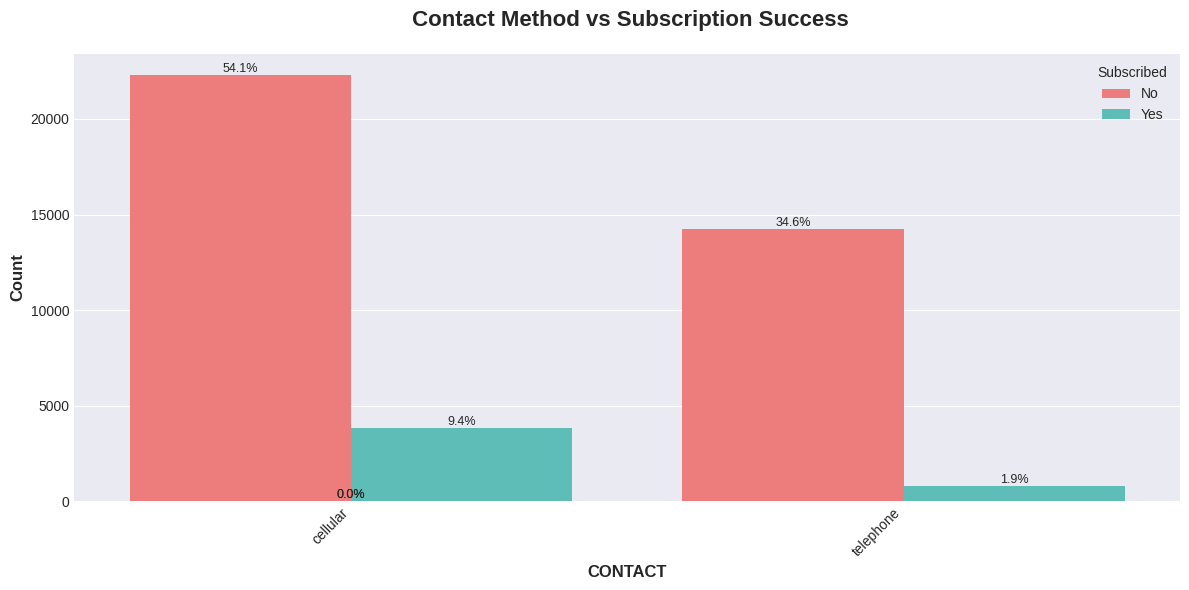


📊 Conversion Rate by Contact Type:
contact
cellular     14.737607
telephone     5.231321
Name: y, dtype: float64


In [81]:
# Contact-related features analysis
contact_features = ['contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous']

# 1. Contact type effectiveness
if 'contact' in df.columns:
    fig = create_count_plot(df, 'contact',
                            ' Contact Method vs Subscription Success',
                            color_map={'no': '#FF6B6B', 'yes': '#4ECDC4'})
    plt.show()

    # Calculate conversion rates
    contact_conversion = df.groupby('contact')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100)
    print("\n📊 Conversion Rate by Contact Type:")
    print(contact_conversion.sort_values(ascending=False))

In [82]:
# 2. Monthly campaign performance
if 'month' in df.columns:
    # Order months correctly
    month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
                   'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

    # Calculate metrics by month
    monthly_data = df.groupby('month').agg({
        'y': [('Total_Contacts', 'count'),
              ('Successes', lambda x: (x=='yes').sum()),
              ('Conversion_Rate', lambda x: (x=='yes').sum() / len(x) * 100)]
    }).round(2)
    monthly_data.columns = ['Total_Contacts', 'Successes', 'Conversion_Rate']

    # Reindex to correct month order
    monthly_data = monthly_data.reindex([m for m in month_order if m in monthly_data.index])

    # Create dual-axis plot
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    fig.add_trace(
        go.Bar(x=monthly_data.index, y=monthly_data['Total_Contacts'],
               name='Total Contacts', marker_color='lightblue'),
        secondary_y=False
    )

    fig.add_trace(
        go.Scatter(x=monthly_data.index, y=monthly_data['Conversion_Rate'],
                   name='Conversion Rate (%)', mode='lines+markers',
                   line=dict(color='red', width=3), marker=dict(size=10)),
        secondary_y=True
    )

    fig.update_layout(title_text="📅 Campaign Performance by Month: Volume vs Conversion",
                      height=500, hovermode='x unified')
    fig.update_xaxes(title_text="Month")
    fig.update_yaxes(title_text="Number of Contacts", secondary_y=False)
    fig.update_yaxes(title_text="Conversion Rate (%)", secondary_y=True)
    fig.show()

    print("\n📊 Best & Worst Performing Months:")
    print("\nTop 3 Months (by conversion rate):")
    print(monthly_data.nlargest(3, 'Conversion_Rate')[['Total_Contacts', 'Conversion_Rate']])
    print("\nBottom 3 Months:")
    print(monthly_data.nsmallest(3, 'Conversion_Rate')[['Total_Contacts', 'Conversion_Rate']])


📊 Best & Worst Performing Months:

Top 3 Months (by conversion rate):
       Total_Contacts  Conversion_Rate
month                                 
mar               546            50.55
dec               182            48.90
sep               570            44.91

Bottom 3 Months:
       Total_Contacts  Conversion_Rate
month                                 
may             13769             6.43
jul              7174             9.05
nov              4101            10.14


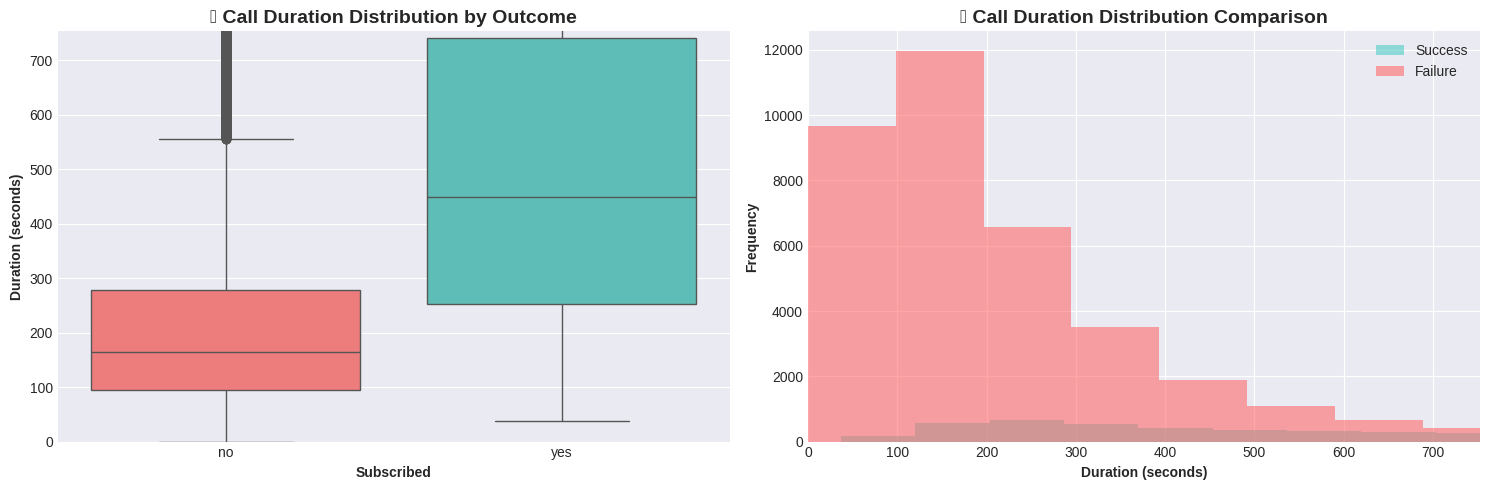


📊 Call Duration Statistics:
       count        mean         std   min    25%    50%     75%     max
y                                                                       
no   36548.0  220.844807  207.096293   0.0   95.0  163.5  279.00  4918.0
yes   4640.0  553.191164  401.171871  37.0  253.0  449.0  741.25  4199.0

💡 Key Insight: Successful calls are 2.50x longer on average


In [83]:
# 3. Call duration analysis
if 'duration' in df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # Box plot by outcome
    sns.boxplot(data=df, x='y', y='duration', ax=axes[0], palette={'no': '#FF6B6B', 'yes': '#4ECDC4'})
    axes[0].set_title('📞 Call Duration Distribution by Outcome', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Subscribed', fontweight='bold')
    axes[0].set_ylabel('Duration (seconds)', fontweight='bold')
    axes[0].set_ylim(0, df['duration'].quantile(0.95))  # Remove extreme outliers for clarity

    # Histogram comparison
    df[df['y']=='yes']['duration'].hist(bins=50, alpha=0.6, label='Success', color='#4ECDC4', ax=axes[1])
    df[df['y']=='no']['duration'].hist(bins=50, alpha=0.6, label='Failure', color='#FF6B6B', ax=axes[1])
    axes[1].set_title('📊 Call Duration Distribution Comparison', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Duration (seconds)', fontweight='bold')
    axes[1].set_ylabel('Frequency', fontweight='bold')
    axes[1].legend()
    axes[1].set_xlim(0, df['duration'].quantile(0.95))

    plt.tight_layout()
    plt.show()

    print("\n📊 Call Duration Statistics:")
    print(df.groupby('y')['duration'].describe())
    print(f"\n💡 Key Insight: Successful calls are {df[df['y']=='yes']['duration'].mean() / df[df['y']=='no']['duration'].mean():.2f}x longer on average")

#2.3 Customer Demographics Analysis
**Business Question:** Which customer segments are most likely to subscribe?

In [84]:
# Demographic features
demographic_features = ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan']

# 1. Age analysis
if 'age' in df.columns:
    # Create age groups
    df['age_group'] = pd.cut(df['age'], bins=[0, 25, 35, 45, 55, 65, 100],
                              labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

    # Calculate conversion by age group
    age_conversion = df.groupby('age_group').agg({
        'y': [('count', 'count'), ('success_rate', lambda x: (x=='yes').sum() / len(x) * 100)]
    })
    age_conversion.columns = ['Total', 'Conversion_Rate']

    # Visualization
    fig = make_subplots(specs=[[{"secondary_y": True}]])

    fig.add_trace(
        go.Bar(x=age_conversion.index, y=age_conversion['Total'],
               name='Total Customers', marker_color='lightcoral'),
        secondary_y=False
    )

    fig.add_trace(
        go.Scatter(x=age_conversion.index, y=age_conversion['Conversion_Rate'],
                   name='Conversion Rate', mode='lines+markers',
                   line=dict(color='darkgreen', width=3), marker=dict(size=12)),
        secondary_y=True
    )

    fig.update_layout(title_text="👤 Customer Age Groups: Volume vs Conversion", height=500)
    fig.update_xaxes(title_text="Age Group")
    fig.update_yaxes(title_text="Number of Customers", secondary_y=False)
    fig.update_yaxes(title_text="Conversion Rate (%)", secondary_y=True)
    fig.show()

    print("\n📊 Conversion Rate by Age Group:")
    print(age_conversion)


📊 Conversion Rate by Age Group:
           Total  Conversion_Rate
age_group                        
18-25       1666        20.948379
26-35      14847        11.719539
36-45      12844         8.509810
46-55       8249         8.691963
56-65       2963        15.221060
65+          619        46.849758


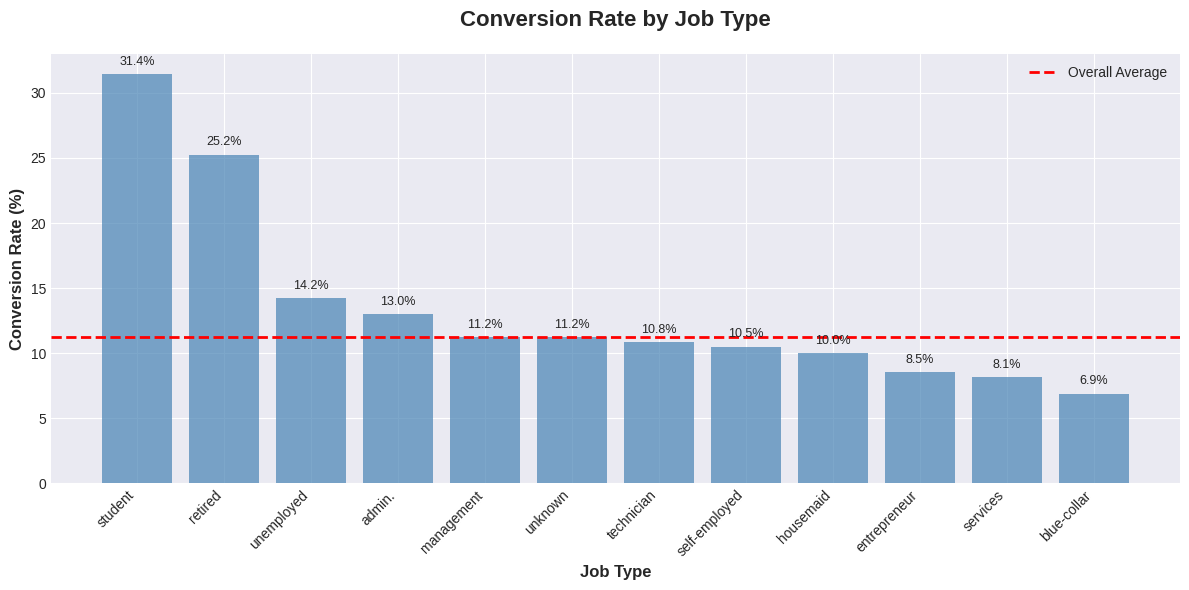


📊 Top 5 Jobs by Conversion Rate:
            Total  Conversion_Rate
job                               
student       875        31.428571
retired      1720        25.232558
unemployed   1014        14.201183
admin.      10422        12.972558
management   2924        11.217510

📊 Bottom 5 Jobs:
               Total  Conversion_Rate
job                                  
self-employed   1421        10.485574
housemaid       1060        10.000000
entrepreneur    1456         8.516484
services        3969         8.138070
blue-collar     9254         6.894316


In [85]:
# 2. Job type analysis
if 'job' in df.columns:
    job_conversion = df.groupby('job').agg({
        'y': [('count', 'count'), ('success_rate', lambda x: (x=='yes').sum() / len(x) * 100)]
    })
    job_conversion.columns = ['Total', 'Conversion_Rate']
    job_conversion = job_conversion.sort_values('Conversion_Rate', ascending=False)

    fig, ax = plt.subplots(figsize=(12, 6))
    x = range(len(job_conversion))
    ax.bar(x, job_conversion['Conversion_Rate'], color='steelblue', alpha=0.7)
    ax.set_xticks(x)
    ax.set_xticklabels(job_conversion.index, rotation=45, ha='right')
    ax.set_title('Conversion Rate by Job Type', fontsize=16, fontweight='bold', pad=20)
    ax.set_xlabel('Job Type', fontsize=12, fontweight='bold')
    ax.set_ylabel('Conversion Rate (%)', fontsize=12, fontweight='bold')
    ax.axhline(y=df['y'].value_counts(normalize=True)['yes']*100,
               color='red', linestyle='--', label='Overall Average', linewidth=2)
    ax.legend()

    # Add value labels
    for i, v in enumerate(job_conversion['Conversion_Rate']):
        ax.text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=9)

    plt.tight_layout()
    plt.show()

    print("\n📊 Top 5 Jobs by Conversion Rate:")
    print(job_conversion.head())
    print("\n📊 Bottom 5 Jobs:")
    print(job_conversion.tail())

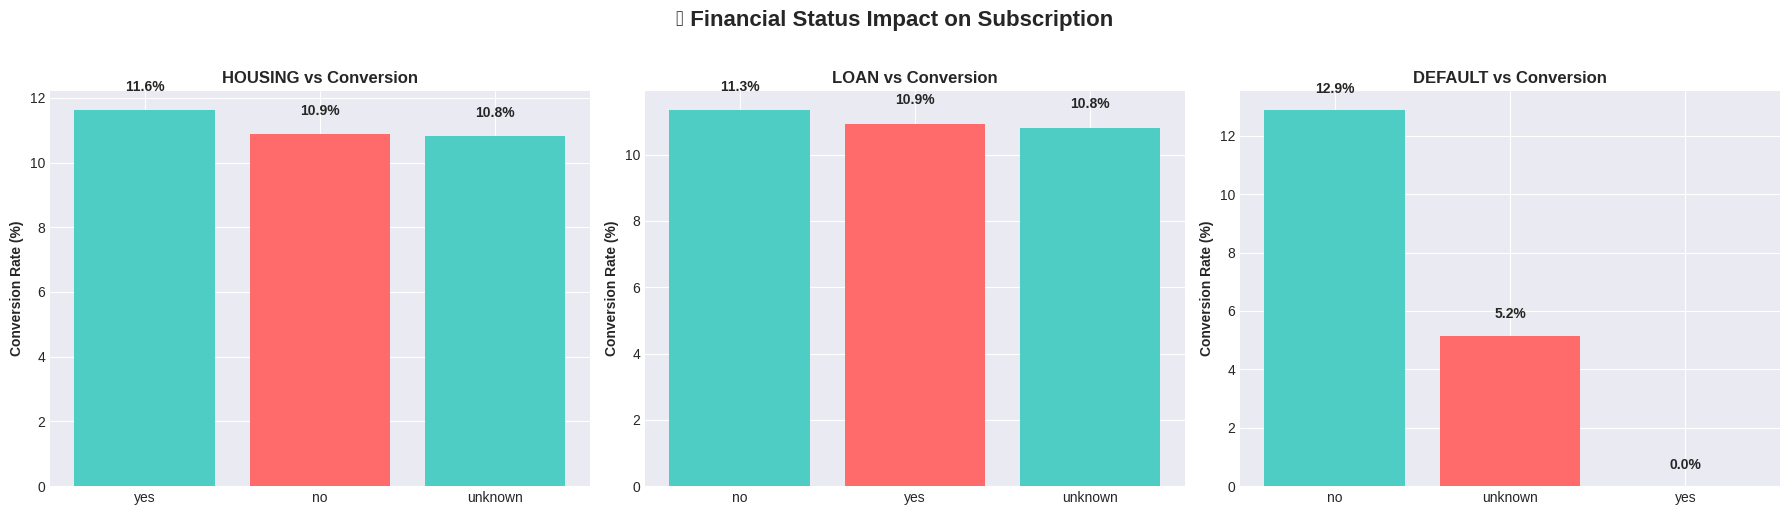


💡 Key Financial Insights:

HOUSING:
housing
no         10.879605
unknown    10.808081
yes        11.619392
Name: y, dtype: float64

LOAN:
loan
no         11.340206
unknown    10.808081
yes        10.931498
Name: y, dtype: float64

DEFAULT:
default
no         12.878974
unknown     5.152960
yes         0.000000
Name: y, dtype: float64


In [86]:
# 3. Financial status analysis
financial_features = ['housing', 'loan', 'default']

if all(f in df.columns for f in financial_features):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    for idx, feature in enumerate(financial_features):
        feature_conversion = df.groupby(feature)['y'].apply(
            lambda x: (x=='yes').sum() / len(x) * 100
        ).sort_values(ascending=False)

        axes[idx].bar(range(len(feature_conversion)), feature_conversion.values,
                      color=['#4ECDC4', '#FF6B6B'])
        axes[idx].set_xticks(range(len(feature_conversion)))
        axes[idx].set_xticklabels(feature_conversion.index)
        axes[idx].set_title(f'{feature.upper()} vs Conversion', fontsize=12, fontweight='bold')
        axes[idx].set_ylabel('Conversion Rate (%)', fontweight='bold')

        # Add value labels
        for i, v in enumerate(feature_conversion.values):
            axes[idx].text(i, v + 0.5, f'{v:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

    plt.suptitle('💰 Financial Status Impact on Subscription', fontsize=16, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    print("\n💡 Key Financial Insights:")
    for feature in financial_features:
        conversion = df.groupby(feature)['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100)
        print(f"\n{feature.upper()}:")
        print(conversion)

#2.4 Economic Context Analysis
**Research Insight:** The paper found that Euribor rate was the #1 predictor. Let's validate this.

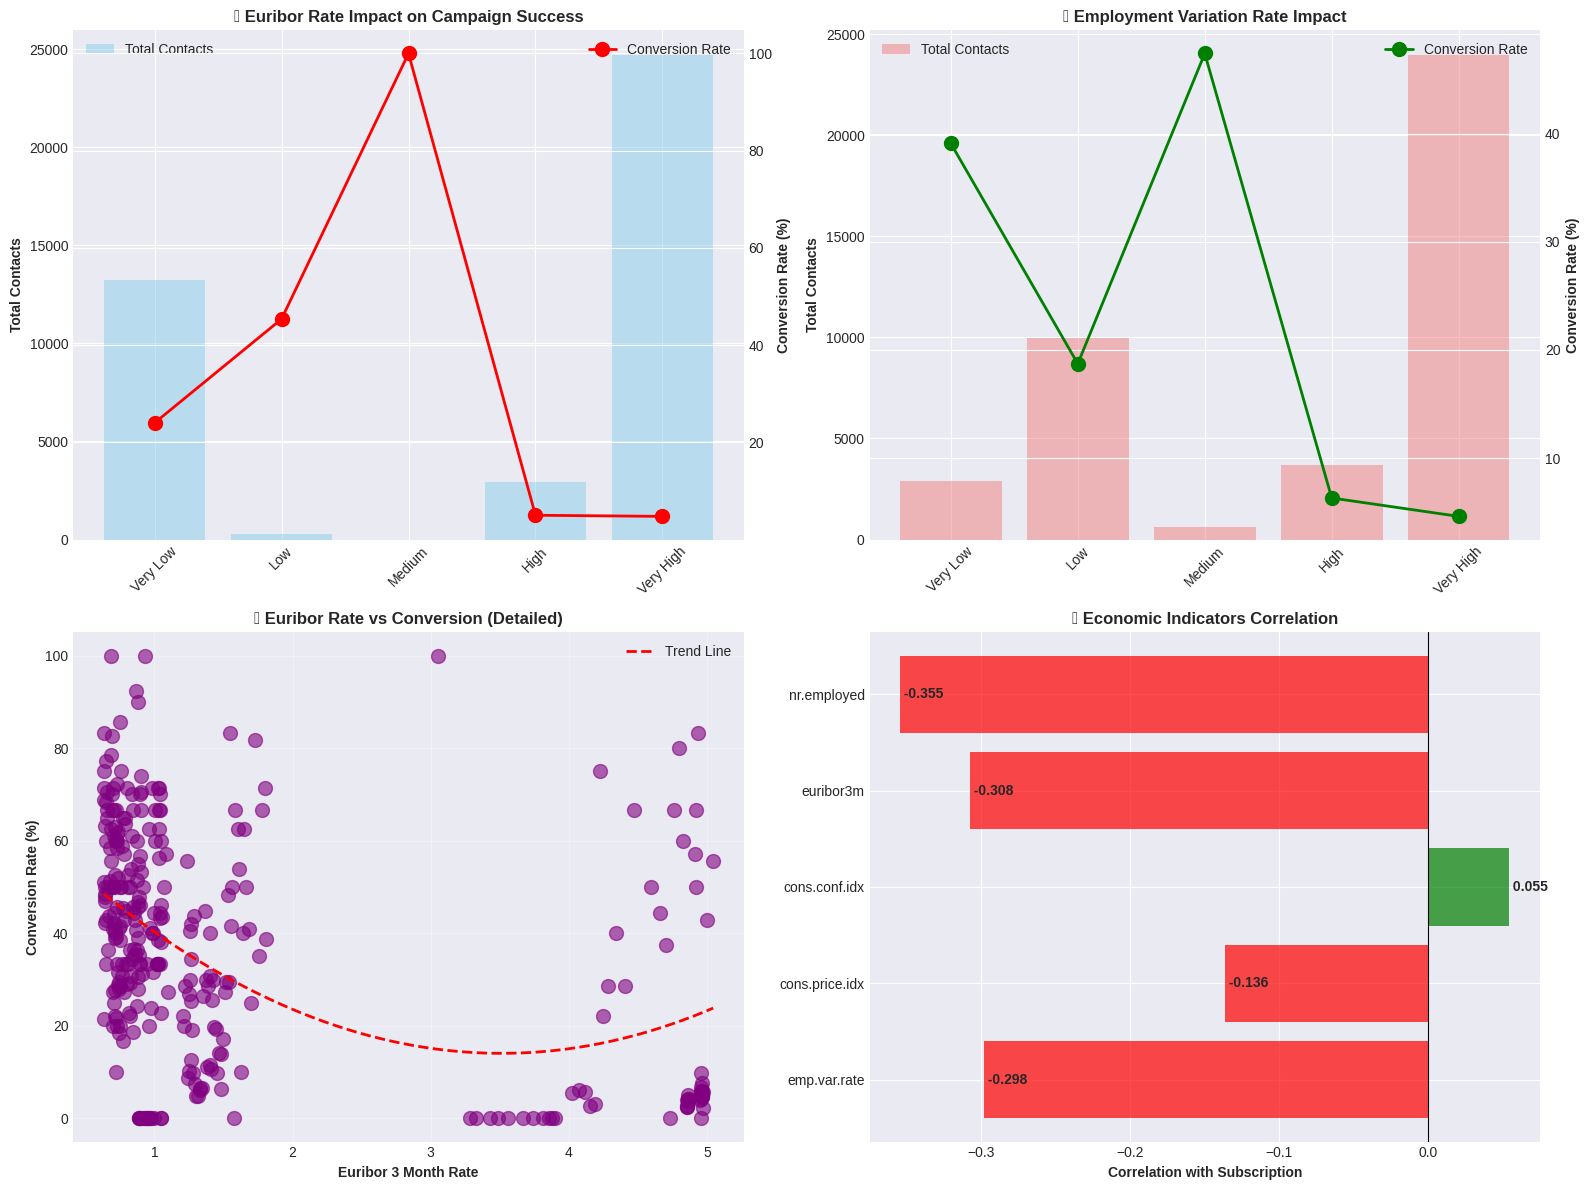


🌍 ECONOMIC CONTEXT INSIGHTS:

📊 Euribor Impact:
               Total  Conversion_Rate
euribor_level                        
Very Low       13227        24.026612
Low              271        45.387454
Medium             1       100.000000
High            2957         5.038891
Very High      24732         4.807537

💡 Key Finding: Conversion rate is 20.80x higher when Euribor is at 'Medium' level

📊 Economic Indicators Correlation:
cons.conf.idx     0.054878
cons.price.idx   -0.136211
emp.var.rate     -0.298334
euribor3m        -0.307771
nr.employed      -0.354678
Name: y_numeric, dtype: float64

💡 This validates the research paper's finding: Economic indicators (especially Euribor) are crucial!


In [87]:
# Economic indicators
economic_features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

if all(f in df.columns for f in economic_features):
    # Create bins for economic indicators
    df['euribor_level'] = pd.cut(df['euribor3m'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
    df['emp_var_level'] = pd.cut(df['emp.var.rate'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])

    # Economic impact analysis
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))

    # 1. Euribor impact
    euribor_conversion = df.groupby('euribor_level').agg({
        'y': [('count', 'count'), ('conversion', lambda x: (x=='yes').sum() / len(x) * 100)]
    })
    euribor_conversion.columns = ['Total', 'Conversion_Rate']

    ax1 = axes[0, 0]
    x = range(len(euribor_conversion))
    ax1_twin = ax1.twinx()
    ax1.bar(x, euribor_conversion['Total'], alpha=0.5, color='skyblue', label='Total Contacts')
    ax1_twin.plot(x, euribor_conversion['Conversion_Rate'], 'ro-', linewidth=2, markersize=10, label='Conversion Rate')
    ax1.set_xticks(x)
    ax1.set_xticklabels(euribor_conversion.index, rotation=45)
    ax1.set_title('📊 Euribor Rate Impact on Campaign Success', fontsize=12, fontweight='bold')
    ax1.set_ylabel('Total Contacts', fontweight='bold')
    ax1_twin.set_ylabel('Conversion Rate (%)', fontweight='bold')
    ax1.legend(loc='upper left')
    ax1_twin.legend(loc='upper right')

    # 2. Employment variation impact
    emp_conversion = df.groupby('emp_var_level').agg({
        'y': [('count', 'count'), ('conversion', lambda x: (x=='yes').sum() / len(x) * 100)]
    })
    emp_conversion.columns = ['Total', 'Conversion_Rate']

    ax2 = axes[0, 1]
    x = range(len(emp_conversion))
    ax2_twin = ax2.twinx()
    ax2.bar(x, emp_conversion['Total'], alpha=0.5, color='lightcoral', label='Total Contacts')
    ax2_twin.plot(x, emp_conversion['Conversion_Rate'], 'go-', linewidth=2, markersize=10, label='Conversion Rate')
    ax2.set_xticks(x)
    ax2.set_xticklabels(emp_conversion.index, rotation=45)
    ax2.set_title('📊 Employment Variation Rate Impact', fontsize=12, fontweight='bold')
    ax2.set_ylabel('Total Contacts', fontweight='bold')
    ax2_twin.set_ylabel('Conversion Rate (%)', fontweight='bold')
    ax2.legend(loc='upper left')
    ax2_twin.legend(loc='upper right')

    # 3. Scatter: Euribor vs Conversion
    ax3 = axes[1, 0]
    euribor_detailed = df.groupby('euribor3m')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100)
    ax3.scatter(euribor_detailed.index, euribor_detailed.values, alpha=0.6, s=100, c='purple')
    z = np.polyfit(euribor_detailed.index, euribor_detailed.values, 2)
    p = np.poly1d(z)
    x_line = np.linspace(euribor_detailed.index.min(), euribor_detailed.index.max(), 100)
    ax3.plot(x_line, p(x_line), "r--", linewidth=2, label='Trend Line')
    ax3.set_xlabel('Euribor 3 Month Rate', fontweight='bold')
    ax3.set_ylabel('Conversion Rate (%)', fontweight='bold')
    ax3.set_title('📈 Euribor Rate vs Conversion (Detailed)', fontsize=12, fontweight='bold')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Economic indicators correlation with success
    ax4 = axes[1, 1]
    economic_data = df[economic_features + ['y']].copy()
    economic_data['y_numeric'] = (economic_data['y'] == 'yes').astype(int)
    corr_with_target = economic_data[economic_features + ['y_numeric']].corr()['y_numeric'].drop('y_numeric')
    colors = ['green' if x > 0 else 'red' for x in corr_with_target.values]
    ax4.barh(range(len(corr_with_target)), corr_with_target.values, color=colors, alpha=0.7)
    ax4.set_yticks(range(len(corr_with_target)))
    ax4.set_yticklabels(corr_with_target.index)
    ax4.set_xlabel('Correlation with Subscription', fontweight='bold')
    ax4.set_title('🔗 Economic Indicators Correlation', fontsize=12, fontweight='bold')
    ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8)

    # Add value labels
    for i, v in enumerate(corr_with_target.values):
        ax4.text(v, i, f' {v:.3f}', va='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    print("\n🌍 ECONOMIC CONTEXT INSIGHTS:")
    print("=" * 60)
    print("\n📊 Euribor Impact:")
    print(euribor_conversion)
    print(f"\n💡 Key Finding: Conversion rate is {euribor_conversion['Conversion_Rate'].max() / euribor_conversion['Conversion_Rate'].min():.2f}x higher "
          f"when Euribor is at '{euribor_conversion['Conversion_Rate'].idxmax()}' level")

    print("\n📊 Economic Indicators Correlation:")
    print(corr_with_target.sort_values(ascending=False))
    print("\n💡 This validates the research paper's finding: Economic indicators (especially Euribor) are crucial!")

In [88]:
# Quick diagnostic
print("📋 Checking for economic features...")
economic_features = ['emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

for feature in economic_features:
    if feature in df.columns:
        print(f"  ✅ {feature}")
    else:
        print(f"  ❌ {feature} - MISSING")

print(f"\n📊 Your columns: {df.columns.tolist()}")

📋 Checking for economic features...
  ✅ emp.var.rate
  ✅ cons.price.idx
  ✅ cons.conf.idx
  ✅ euribor3m
  ✅ nr.employed

📊 Your columns: ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'duration', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y', 'age_group', 'euribor_level', 'emp_var_level']


#2.5 Feature Correlation Heatmap

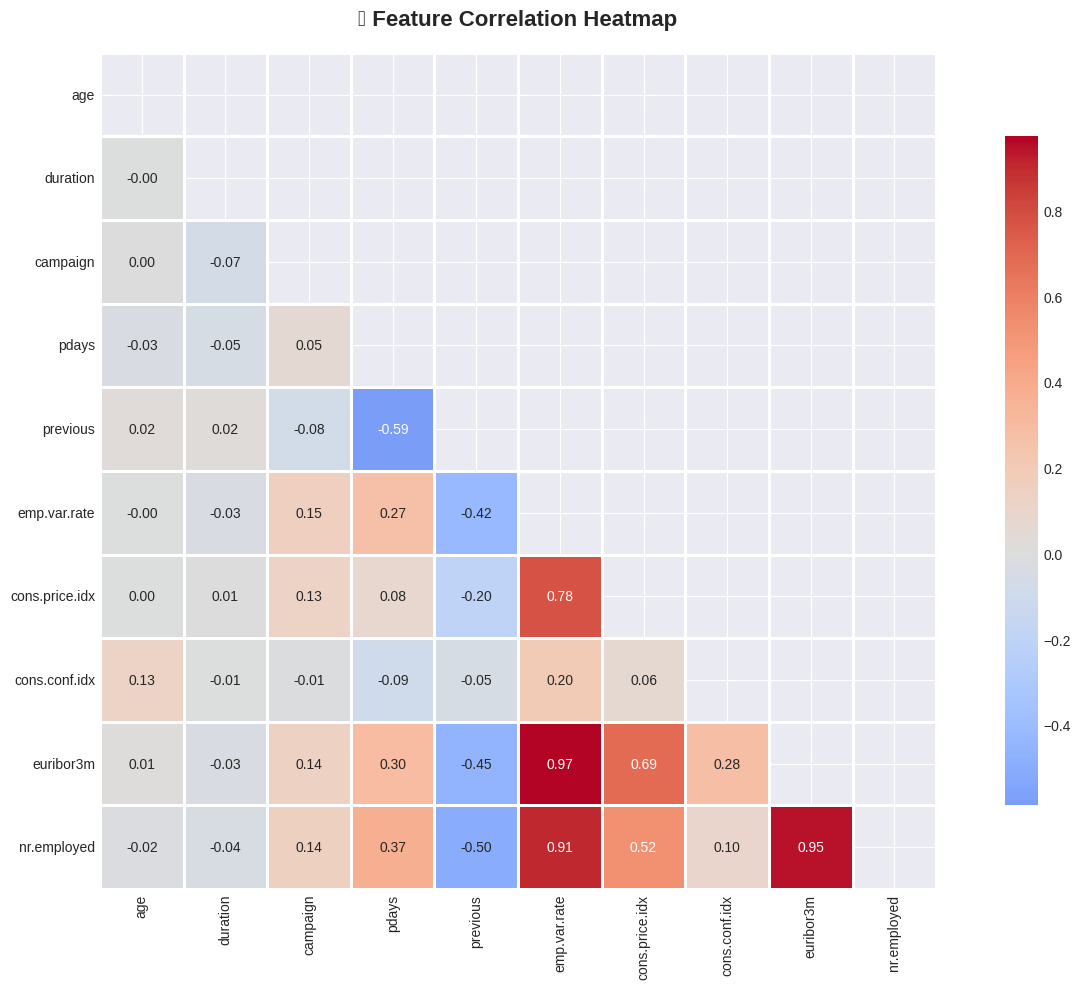


⚠️ Highly Correlated Features (|correlation| > 0.7):
  • emp.var.rate ↔ cons.price.idx: 0.775
  • emp.var.rate ↔ euribor3m: 0.972
  • emp.var.rate ↔ nr.employed: 0.907
  • euribor3m ↔ nr.employed: 0.945

💡 Consider removing one feature from each pair to reduce multicollinearity.


In [89]:
# Select numeric features for correlation
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Calculate correlation matrix
corr_matrix = df[numeric_cols].corr()

# Create correlation heatmap
plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('🔥 Feature Correlation Heatmap', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Find highly correlated features
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr:
    print("\n⚠️ Highly Correlated Features (|correlation| > 0.7):")
    for feat1, feat2, corr in high_corr:
        print(f"  • {feat1} ↔ {feat2}: {corr:.3f}")
    print("\n💡 Consider removing one feature from each pair to reduce multicollinearity.")
else:
    print("\n✅ No severe multicollinearity detected (all correlations < 0.7)")

#📊 EDA Summary

In [90]:
print("\n" + "="*80)
print("🎯 KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS")
print("="*80)

print("\n1️⃣ CLASS IMBALANCE:")
print(f"   • Success rate: {(df['y']=='yes').sum() / len(df) * 100:.2f}%")


if 'duration' in df.columns:
    avg_success_duration = df[df['y']=='yes']['duration'].mean()
    avg_fail_duration = df[df['y']=='no']['duration'].mean()
    print(f"\n2️⃣ CALL DURATION:")
    print(f"   • Successful calls: {avg_success_duration:.0f} seconds average")
    print(f"   • Failed calls: {avg_fail_duration:.0f} seconds average")
    print(f"   • Success calls are {avg_success_duration/avg_fail_duration:.2f}x longer")

if 'contact' in df.columns:
    print(f"\n3️⃣ CONTACT METHOD:")
    contact_rates = df.groupby('contact')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100)
    best_contact = contact_rates.idxmax()
    print(f"   • Best method: {best_contact} ({contact_rates[best_contact]:.2f}% conversion)")

if 'month' in df.columns:
    monthly_conv = df.groupby('month')['y'].apply(lambda x: (x=='yes').sum() / len(x) * 100)
    print(f"\n4️⃣ SEASONALITY:")
    print(f"   • Best month: {monthly_conv.idxmax()} ({monthly_conv.max():.2f}% conversion)")
    print(f"   • Worst month: {monthly_conv.idxmin()} ({monthly_conv.min():.2f}% conversion)")

if 'euribor3m' in df.columns:
    print(f"\n5️⃣ ECONOMIC CONTEXT:")
    print(f"   • Euribor range: {df['euribor3m'].min():.3f}% to {df['euribor3m'].max():.3f}%")
    print("   • Lower Euribor rates correlate with higher conversion")
    print("   • Validates research paper finding: Economic indicators are crucial")

print("\n" + "="*80)


🎯 KEY INSIGHTS FROM EXPLORATORY DATA ANALYSIS

1️⃣ CLASS IMBALANCE:
   • Success rate: 11.27%

2️⃣ CALL DURATION:
   • Successful calls: 553 seconds average
   • Failed calls: 221 seconds average
   • Success calls are 2.50x longer

3️⃣ CONTACT METHOD:
   • Best method: cellular (14.74% conversion)

4️⃣ SEASONALITY:
   • Best month: mar (50.55% conversion)
   • Worst month: may (6.43% conversion)

5️⃣ ECONOMIC CONTEXT:
   • Euribor range: 0.634% to 5.045%
   • Lower Euribor rates correlate with higher conversion
   • Validates research paper finding: Economic indicators are crucial



#MODELLING

In [91]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Modeling libraries
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, roc_curve
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
from sklearn.utils import resample

print("="*80)
print("Bank Marketing Campaign Optimizer - MODELING PHASE")
print("="*80)

print("\n📋 IMPLEMENTATION DETAILS:")
print("   ✓ Downsampling ratio: 3:1 (majority:minority)")
print("   ✓ Duration feature: EXCLUDED (confounder)")
print("   ✓ Models: 4 (Logistic Regression, Random Forest, XGBoost, Neural Network)")
print("   ✓ Cross-validation: TimeSeriesSplit (5 folds)")
print("   ✓ Feature engineering: 3 new features created")

Bank Marketing Campaign Optimizer - MODELING PHASE

📋 IMPLEMENTATION DETAILS:
   ✓ Downsampling ratio: 3:1 (majority:minority)
   ✓ Duration feature: EXCLUDED (confounder)
   ✓ Models: 4 (Logistic Regression, Random Forest, XGBoost, Neural Network)
   ✓ Cross-validation: TimeSeriesSplit (5 folds)
   ✓ Feature engineering: 3 new features created


In [92]:
# ============================================================================
# STEP 1: DATA LOADING
# ============================================================================

print("\n" + "="*80)
print("STEP 1: DATA LOADING & INITIAL PREPARATION")
print("="*80)

df = pd.read_csv("bank-additional-full.csv", sep=";")

print(f"\n✅ Data loaded successfully")
print(f"   Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"   Period: 2008-2013")

# Display first few rows
print(f"\n📊 Preview of data:")
print(df.head(3))


STEP 1: DATA LOADING & INITIAL PREPARATION

✅ Data loaded successfully
   Shape: 41,188 rows × 21 columns
   Period: 2008-2013

📊 Preview of data:
   age        job  marital    education  default housing loan    contact  \
0   56  housemaid  married     basic.4y       no      no   no  telephone   
1   57   services  married  high.school  unknown      no   no  telephone   
2   37   services  married  high.school       no     yes   no  telephone   

  month day_of_week  duration  campaign  pdays  previous     poutcome  \
0   may         mon       261         1    999         0  nonexistent   
1   may         mon       149         1    999         0  nonexistent   
2   may         mon       226         1    999         0  nonexistent   

   emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed   y  
0           1.1          93.994          -36.4      4.857       5191.0  no  
1           1.1          93.994          -36.4      4.857       5191.0  no  
2           1.1        

In [93]:
# ============================================================================
# STEP 2: EXCLUDE DURATION (CONFOUNDER)
# ============================================================================

print("\n" + "="*80)
print("STEP 2: FEATURE SELECTION")
print("❌ EXCLUDING duration feature (confounder)")
print("="*80)

# Remove duration as per professor's instruction
df = df.drop(columns=["duration"])

print(f"✅ Duration feature excluded")
print(f"   Remaining features: {df.shape[1] - 1}")  # -1 for target


STEP 2: FEATURE SELECTION
❌ EXCLUDING duration feature (confounder)
✅ Duration feature excluded
   Remaining features: 19


In [94]:
# ============================================================================
# STEP 3: TARGET ENCODING & FEATURE ENGINEERING
# ============================================================================

print("\n" + "="*80)
print("STEP 3: TARGET ENCODING & FEATURE ENGINEERING")
print("="*80)

# Encode target variable
df["y"] = df["y"].map({"yes": 1, "no": 0})

print(f"✅ Target encoded: 0='no', 1='yes'")

# Check class distribution
y_counts = df["y"].value_counts()
print(f"\n📊 Class distribution:")
print(f"   No (0): {y_counts[0]:,} ({y_counts[0]/len(df)*100:.1f}%)")
print(f"   Yes (1): {y_counts[1]:,} ({y_counts[1]/len(df)*100:.1f}%)")
print(f"   Imbalance ratio: 1:{y_counts[0]/y_counts[1]:.1f}")

# Feature Engineering
print(f"\n🔧 Creating engineered features...")

# 1. Economic pressure indicator (interaction of economic variables)
df["econ_pressure"] = df["euribor3m"] * df["emp.var.rate"]
print(f"   ✓ econ_pressure (euribor3m × emp.var.rate)")

# 2. Contact intensity (total contact attempts)
df["contact_intensity"] = df["campaign"] + df["previous"]
print(f"   ✓ contact_intensity (campaign + previous)")

# 3. First contact flag (never contacted before)
df["first_contact"] = (df["pdays"] == 999).astype(int)
print(f"   ✓ first_contact (pdays == 999)")

print(f"\n✅ Created 3 engineered features")
print(f"   Total features now: {df.shape[1] - 1}")  # -1 for target


STEP 3: TARGET ENCODING & FEATURE ENGINEERING
✅ Target encoded: 0='no', 1='yes'

📊 Class distribution:
   No (0): 36,548 (88.7%)
   Yes (1): 4,640 (11.3%)
   Imbalance ratio: 1:7.9

🔧 Creating engineered features...
   ✓ econ_pressure (euribor3m × emp.var.rate)
   ✓ contact_intensity (campaign + previous)
   ✓ first_contact (pdays == 999)

✅ Created 3 engineered features
   Total features now: 22



UNSUPERVISED CUSTOMER SEGMENTS (CLUSTERING)

 Using 11 numeric features for clustering:
['age', 'campaign', 'pdays', 'previous', 'euribor3m', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'nr.employed', 'contact_intensity', 'econ_pressure']
Samples after NA removal: 41,188


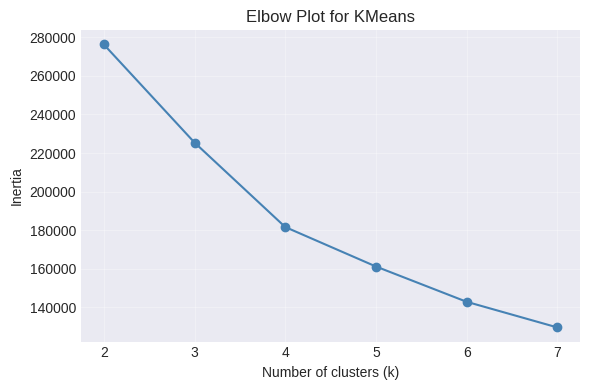


✅ Assigned 4 clusters to 41,188 customers.

📊 Cluster-level summary:
         n_customers  conversion_rate  avg_age  avg_contact_intensity  \
cluster                                                                 
0              26079             4.89    40.18                   2.23   
1               1554            62.81    41.87                   3.54   
2              11941            19.48    39.40                   2.40   
3               1614             3.90    40.45                  12.81   

         avg_euribor  avg_emp_var  
cluster                            
0               4.81         1.11  
1               0.98        -2.09  
2               1.20        -2.03  
3               4.81         1.22  


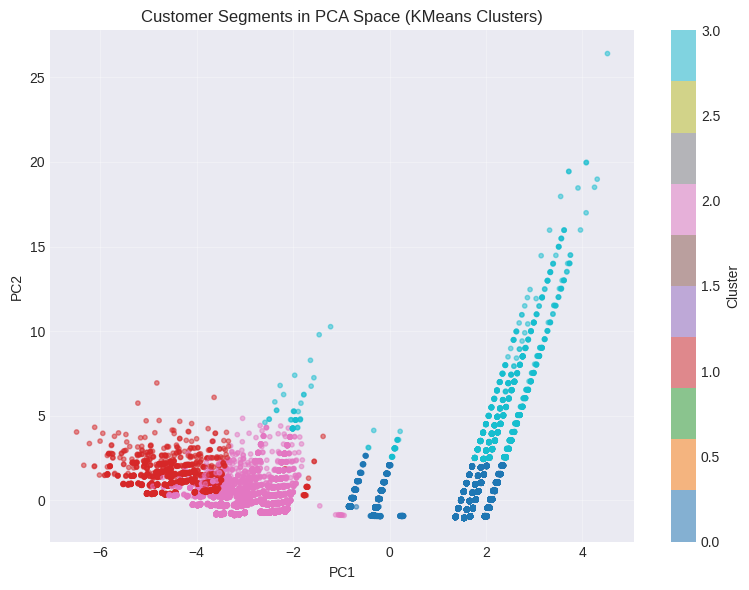

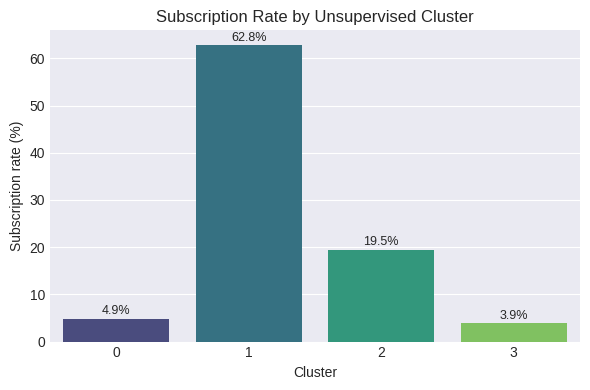

In [95]:
# ===============================
# UNSUPERVISED SEGMENTATION (CLUSTERING)
# ===============================
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

print("\n" + "="*80)
print("UNSUPERVISED CUSTOMER SEGMENTS (CLUSTERING)")
print("="*80)

# Select mainly numeric features for clustering
cluster_features = [
    "age", "campaign", "pdays", "previous",
    "euribor3m", "emp.var.rate", "cons.price.idx",
    "cons.conf.idx", "nr.employed",
    "contact_intensity", "econ_pressure"
]

# Keep only features that actually exist
cluster_features = [f for f in cluster_features if f in df.columns]
cluster_df = df[cluster_features].copy()

# Drop rows with any missing numeric values used for clustering
cluster_df = cluster_df.replace([np.inf, -np.inf], np.nan).dropna()

print(f"\n Using {len(cluster_features)} numeric features for clustering:")
print(cluster_features)
print(f"Samples after NA removal: {cluster_df.shape[0]:,}")

# Standardize
scaler_clust = StandardScaler()
X_clust = scaler_clust.fit_transform(cluster_df)

# Optional: choose k via elbow method
inertias = []
K_range = range(2, 8)
for k in K_range:
    km_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    km_tmp.fit(X_clust)
    inertias.append(km_tmp.inertia_)

plt.figure(figsize=(6, 4))
plt.plot(K_range, inertias, "o-", color="steelblue")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Plot for KMeans")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Choose k (e.g., 4 clusters) based on elbow + interpretability
k_opt = 4
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=20)
cluster_labels = kmeans.fit_predict(X_clust)

# Attach cluster labels back to main df
df["cluster"] = -1
df.loc[cluster_df.index, "cluster"] = cluster_labels

print(f"\n✅ Assigned {k_opt} clusters to {cluster_df.shape[0]:,} customers.")

# Cluster-level summary
cluster_summary = df[df["cluster"] >= 0].groupby("cluster").agg(
    n_customers=("cluster", "size"),
    conversion_rate=("y", lambda x: (x == 1).mean() * 100),
    avg_age=("age", "mean"),
    avg_contact_intensity=("contact_intensity", "mean"),
    avg_euribor=("euribor3m", "mean"),
    avg_emp_var=("emp.var.rate", "mean")
).round(2)

print("\n📊 Cluster-level summary:")
print(cluster_summary)

# PCA for 2D visualization
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_clust)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca[:, 0], X_pca[:, 1],
    c=cluster_labels, cmap="tab10", alpha=0.5, s=10
)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Customer Segments in PCA Space (KMeans Clusters)")
plt.colorbar(scatter, label="Cluster")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Conversion rate by cluster (bar plot)
plt.figure(figsize=(6, 4))
sns.barplot(
    x=cluster_summary.index,
    y=cluster_summary["conversion_rate"],
    palette="viridis"
)
plt.xlabel("Cluster")
plt.ylabel("Subscription rate (%)")
plt.title("Subscription Rate by Unsupervised Cluster")
for i, v in enumerate(cluster_summary["conversion_rate"]):
    plt.text(i, v + 0.3, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.show()

In [96]:
# ============================================================================
# STEP 4: TEMPORAL ORDERING
# ============================================================================

print("\n" + "="*80)
print("STEP 4: TEMPORAL ORDERING")
print("Sorting data chronologically for time-series CV")
print("="*80)

# Create month mapping for temporal ordering
month_map = {
    "jan": 1, "feb": 2, "mar": 3, "apr": 4, "may": 5, "jun": 6,
    "jul": 7, "aug": 8, "sep": 9, "oct": 10, "nov": 11, "dec": 12
}

df["month_num"] = df["month"].map(month_map)
df = df.sort_values("month_num").reset_index(drop=True)

print(f"✅ Data sorted chronologically by month")
print(f"   This ensures temporal validation (train on past, test on future)")


STEP 4: TEMPORAL ORDERING
Sorting data chronologically for time-series CV
✅ Data sorted chronologically by month
   This ensures temporal validation (train on past, test on future)


In [97]:
# ============================================================================
# STEP 5: FEATURE PREPROCESSING
# ============================================================================

print("\n" + "="*80)
print("STEP 5: FEATURE PREPROCESSING")
print("="*80)

# Separate features and target
X = df.drop(columns=["y"])
y = df["y"]

# One-hot encoding for categorical variables
X = pd.get_dummies(X, drop_first=True)

print(f"✅ One-hot encoding completed")
print(f"   Total features after encoding: {X.shape[1]}")
print(f"   Features include:")
print(f"      - Original features (excluding duration)")
print(f"      - Engineered features (3 new)")
print(f"      - One-hot encoded categoricals")


STEP 5: FEATURE PREPROCESSING
✅ One-hot encoding completed
   Total features after encoding: 57
   Features include:
      - Original features (excluding duration)
      - Engineered features (3 new)
      - One-hot encoded categoricals


In [98]:
# ============================================================================
# STEP 6: DOWNSAMPLING FUNCTION
# ============================================================================

print("\n" + "="*80)
print("STEP 6: DOWNSAMPLING FUNCTION")
print("Using 3:1 ratio")
print("="*80)

def downsample(X, y, ratio=3, random_state=42):
    """
    Downsample majority class

    Parameters:
    -----------
    X : DataFrame
        Features
    y : Series
        Target
    ratio : int, default=3
        Ratio of majority to minority (3:1)
    random_state : int
        Random seed

    Returns:
    --------
    X_balanced, y_balanced : Downsampled data
    """
    # Combine for sampling
    data = pd.concat([X, y], axis=1)

    # Separate classes
    majority = data[data.y == 0]
    minority = data[data.y == 1]

    # Downsample majority to ratio × minority
    majority_down = resample(
        majority,
        replace=False,
        n_samples=len(minority) * ratio,
        random_state=random_state
    )

    # Combine and shuffle
    balanced = pd.concat([majority_down, minority])
    balanced = balanced.sample(frac=1, random_state=random_state).reset_index(drop=True)

    # Separate back
    X_bal = balanced.drop("y", axis=1)
    y_bal = balanced["y"]

    return X_bal, y_bal

print(f"✅ Downsampling function defined")
print(f"   Ratio: 3:1 (majority:minority)")
print(f"   Retains ~40% of data (vs 20% with 1:1 ratio)")


STEP 6: DOWNSAMPLING FUNCTION
Using 3:1 ratio
✅ Downsampling function defined
   Ratio: 3:1 (majority:minority)
   Retains ~40% of data (vs 20% with 1:1 ratio)


In [99]:
# ============================================================================
# STEP 7: CROSS-VALIDATION SETUP
# ============================================================================

print("\n" + "="*80)
print("STEP 7: TIME-SERIES CROSS-VALIDATION SETUP")
print("="*80)

# TimeSeriesSplit ensures temporal ordering
tscv = TimeSeriesSplit(n_splits=5)

print(f"✅ TimeSeriesSplit initialized")
print(f"   Number of folds: 5")
print(f"   Validation type: Expanding window")
print(f"   Each fold trains on past data, tests on future")


STEP 7: TIME-SERIES CROSS-VALIDATION SETUP
✅ TimeSeriesSplit initialized
   Number of folds: 5
   Validation type: Expanding window
   Each fold trains on past data, tests on future


In [100]:
# ============================================================================
# STEP 8: MODEL DEFINITIONS
# ============================================================================

print("\n" + "="*80)
print("STEP 8: MODEL CONFIGURATIONS")
print("Optimized hyperparameters for each model")
print("="*80)

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ),

    "XGBoost": XGBClassifier(
        n_estimators=400,
        max_depth=4,           # Conservative to avoid overfitting
        learning_rate=0.05,    # Slower learning for accuracy
        subsample=0.8,         # Sample 80% of data per tree
        colsample_bytree=0.8,  # Sample 80% of features per tree
        eval_metric="logloss",
        random_state=42,
        verbosity=0
    ),

    "Neural Network": MLPClassifier(
        hidden_layer_sizes=(64, 32),
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42,
        verbose=False
    )
}

print(f"✅ 4 models configured:")
print(f"\n   1. Logistic Regression (baseline)")
print(f"      - max_iter: 2000")
print(f"\n   2. Random Forest (ensemble)")
print(f"      - n_estimators: 300 (3× more trees)")
print(f"      - max_depth: 10")
print(f"\n   3. XGBoost (gradient boosting)")
print(f"      - n_estimators: 400 (4× more trees)")
print(f"      - max_depth: 4 (conservative)")
print(f"      - learning_rate: 0.05 (slower, more accurate)")
print(f"\n   4. Neural Network (deep learning)")
print(f"      - hidden_layers: (64, 32)")
print(f"      - early_stopping: True")



STEP 8: MODEL CONFIGURATIONS
Optimized hyperparameters for each model
✅ 4 models configured:

   1. Logistic Regression (baseline)
      - max_iter: 2000

   2. Random Forest (ensemble)
      - n_estimators: 300 (3× more trees)
      - max_depth: 10

   3. XGBoost (gradient boosting)
      - n_estimators: 400 (4× more trees)
      - max_depth: 4 (conservative)
      - learning_rate: 0.05 (slower, more accurate)

   4. Neural Network (deep learning)
      - hidden_layers: (64, 32)
      - early_stopping: True


In [101]:
# ============================================================================
# STEP 9: CROSS-VALIDATION TRAINING
# ============================================================================

print("\n" + "="*80)
print("STEP 9: CROSS-VALIDATION TRAINING")
print("Training all models across 5 temporal folds")
print("="*80)

results = []
fold_num = 1

for train_idx, test_idx in tscv.split(X):

    print(f"\n{'='*80}")
    print(f"FOLD {fold_num}/5")
    print(f"{'='*80}")

    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

    print(f"\nFold {fold_num} sizes:")
    print(f"   Train: {len(y_train):,} samples ({sum(y_train)/len(y_train)*100:.1f}% positive)")
    print(f"   Test:  {len(y_test):,} samples ({sum(y_test)/len(y_test)*100:.1f}% positive)")

    # Downsample training data (3:1 ratio)
    print(f"\n⚖️  Applying downsampling (3:1 ratio)...")
    X_train_bal, y_train_bal = downsample(X_train, y_train, ratio=3)
    print(f"   After downsampling: {len(y_train_bal):,} samples")
    print(f"   Ratio: {sum(y_train_bal==0)/sum(y_train_bal==1):.1f}:1")

    # Train each model
    print(f"\n🤖 Training models:")

    for name, model in models.items():

        X_train_final = X_train_bal.copy()
        X_test_final = X_test.copy()

        # Scale only for models that need it (LR and NN)
        if name in ["Logistic Regression", "Neural Network"]:
            scaler = StandardScaler()
            X_train_final = scaler.fit_transform(X_train_bal)
            X_test_final = scaler.transform(X_test)

        # Train
        model.fit(X_train_final, y_train_bal)

        # Predict
        preds = model.predict(X_test_final)
        probs = model.predict_proba(X_test_final)[:, 1]

        # Evaluate
        auc = roc_auc_score(y_test, probs)
        f1 = f1_score(y_test, preds)
        precision = precision_score(y_test, preds, zero_division=0)
        recall = recall_score(y_test, preds, zero_division=0)

        # Store results
        results.append([fold_num, name, auc, f1, precision, recall])

        print(f"   {name:20s} → AUC:{auc:.4f} F1:{f1:.4f} Precision:{precision:.4f} Recall:{recall:.4f}")

    fold_num += 1

print(f"\n{'='*80}")
print("✅ CROSS-VALIDATION COMPLETE")
print(f"{'='*80}")


STEP 9: CROSS-VALIDATION TRAINING
Training all models across 5 temporal folds

FOLD 1/5

Fold 1 sizes:
   Train: 6,868 samples (13.7% positive)
   Test:  6,864 samples (5.1% positive)

⚖️  Applying downsampling (3:1 ratio)...
   After downsampling: 3,752 samples
   Ratio: 3.0:1

🤖 Training models:
   Logistic Regression  → AUC:0.5872 F1:0.0000 Precision:0.0000 Recall:0.0000
   Random Forest        → AUC:0.6437 F1:0.1316 Precision:0.1311 Recall:0.1322
   XGBoost              → AUC:0.6312 F1:0.1396 Precision:0.0800 Recall:0.5460
   Neural Network       → AUC:0.6360 F1:0.1244 Precision:0.1398 Recall:0.1121

FOLD 2/5

Fold 2 sizes:
   Train: 13,732 samples (9.4% positive)
   Test:  6,864 samples (11.7% positive)

⚖️  Applying downsampling (3:1 ratio)...
   After downsampling: 5,144 samples
   Ratio: 3.0:1

🤖 Training models:
   Logistic Regression  → AUC:0.6126 F1:0.3646 Precision:0.3898 Recall:0.3424
   Random Forest        → AUC:0.7234 F1:0.3541 Precision:0.5526 Recall:0.2605
   XGBoost

In [102]:
# ============================================================================
# STEP 10: AGGREGATE RESULTS
# ============================================================================

print("\n" + "="*80)
print("STEP 10: CROSS-VALIDATION RESULTS SUMMARY")
print("="*80)

# Create results dataframe
results_df = pd.DataFrame(
    results,
    columns=["Fold", "Model", "ROC_AUC", "F1", "Precision", "Recall"]
)

# Calculate average performance
summary = results_df.groupby("Model").agg({
    'ROC_AUC': ['mean', 'std'],
    'F1': ['mean', 'std'],
    'Precision': ['mean', 'std'],
    'Recall': ['mean', 'std']
}).round(4)

print("\n📊 AVERAGE PERFORMANCE ACROSS 5 FOLDS:")
print("="*100)
print(f"{'Model':<25} | {'ROC-AUC':<18} | {'F1-Score':<18} | {'Precision':<18} | {'Recall':<18}")
print("="*100)

for model_name in models.keys():
    row = summary.loc[model_name]
    print(f"{model_name:<25} | "
          f"{row[('ROC_AUC', 'mean')]:.4f}±{row[('ROC_AUC', 'std')]:.3f}   | "
          f"{row[('F1', 'mean')]:.4f}±{row[('F1', 'std')]:.3f}   | "
          f"{row[('Precision', 'mean')]:.4f}±{row[('Precision', 'std')]:.3f}   | "
          f"{row[('Recall', 'mean')]:.4f}±{row[('Recall', 'std')]:.3f}")

print("="*100)

# Identify best model
best_model_name = summary[('ROC_AUC', 'mean')].idxmax()
best_auc = summary.loc[best_model_name, ('ROC_AUC', 'mean')]
best_auc_std = summary.loc[best_model_name, ('ROC_AUC', 'std')]

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   ROC-AUC: {best_auc:.4f} ± {best_auc_std:.3f}")
print(f"   F1-Score: {summary.loc[best_model_name, ('F1', 'mean')]:.4f} ± {summary.loc[best_model_name, ('F1', 'std')]:.3f}")

# Save results
results_df.to_csv('cv_results_detailed.csv', index=False)
summary.to_csv('cv_results_summary.csv')
print(f"\n💾 Results saved:")
print(f"   cv_results_detailed.csv (all folds)")
print(f"   cv_results_summary.csv (averages)")


STEP 10: CROSS-VALIDATION RESULTS SUMMARY

📊 AVERAGE PERFORMANCE ACROSS 5 FOLDS:
Model                     | ROC-AUC            | F1-Score           | Precision          | Recall            
Logistic Regression       | 0.6750±0.087   | 0.3491±0.209   | 0.3757±0.221   | 0.3540±0.265
Random Forest             | 0.7088±0.053   | 0.3836±0.158   | 0.4230±0.177   | 0.3926±0.240
XGBoost                   | 0.7025±0.054   | 0.3861±0.152   | 0.4101±0.201   | 0.4617±0.155
Neural Network            | 0.7085±0.053   | 0.3732±0.156   | 0.4297±0.179   | 0.3760±0.251

🏆 BEST MODEL: Random Forest
   ROC-AUC: 0.7088 ± 0.053
   F1-Score: 0.3836 ± 0.158

💾 Results saved:
   cv_results_detailed.csv (all folds)
   cv_results_summary.csv (averages)


In [103]:
# ============================================================================
# STEP 11: FINAL MODEL TRAINING
# ============================================================================

print("\n" + "="*80)
print("STEP 11: FINAL MODEL TRAINING")
print(f"Training best model ({best_model_name}) on full dataset")
print("="*80)

# Downsample full dataset for final model
print(f"\n⚖️  Downsampling full dataset (3:1 ratio)...")
X_train_bal, y_train_bal = downsample(X, y, ratio=3)
print(f"   Training samples: {len(y_train_bal):,}")
print(f"   Ratio: {sum(y_train_bal==0)/sum(y_train_bal==1):.1f}:1")

# Get best model
best_model = models[best_model_name]

# Scale if needed
X_train_final = X_train_bal.copy()
if best_model_name in ["Logistic Regression", "Neural Network"]:
    scaler = StandardScaler()
    X_train_final = scaler.fit_transform(X_train_bal)

# Train final model
print(f"\n🤖 Training final {best_model_name}...")
best_model.fit(X_train_final, y_train_bal)

print(f"✅ Final model trained and ready for deployment")



STEP 11: FINAL MODEL TRAINING
Training best model (Random Forest) on full dataset

⚖️  Downsampling full dataset (3:1 ratio)...
   Training samples: 18,560
   Ratio: 3.0:1

🤖 Training final Random Forest...
✅ Final model trained and ready for deployment



STEP 12: FEATURE IMPORTANCE ANALYSIS

📊 Analyzing feature importance for Random Forest...


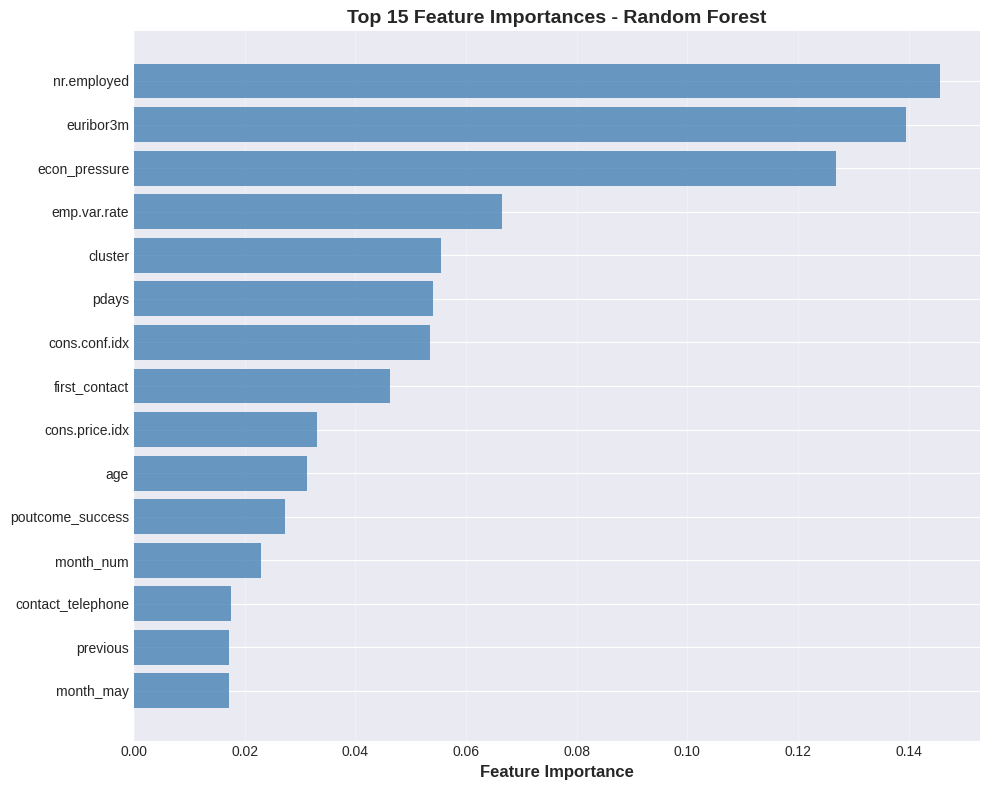

✅ Feature importance plot saved: feature_importance.png

🔝 Top 10 Most Important Features:
    1. nr.employed                    : 0.1456
    2. euribor3m                      : 0.1395
    3. econ_pressure                  : 0.1269
    4. emp.var.rate                   : 0.0665
    5. cluster                        : 0.0555
    6. pdays                          : 0.0540
    7. cons.conf.idx                  : 0.0534
    8. first_contact                  : 0.0462
    9. cons.price.idx                 : 0.0330
   10. age                            : 0.0313


In [104]:
# ============================================================================
# STEP 12: FEATURE IMPORTANCE (if applicable)
# ============================================================================

print("\n" + "="*80)
print("STEP 12: FEATURE IMPORTANCE ANALYSIS")
print("="*80)

if best_model_name in ["Random Forest", "XGBoost"]:

    print(f"\n📊 Analyzing feature importance for {best_model_name}...")

    # Get feature importances
    importance = best_model.feature_importances_
    indices = np.argsort(importance)[-15:]  # Top 15 features

    # Create visualization
    plt.figure(figsize=(10, 8))
    plt.barh(range(len(indices)), importance[indices], color='steelblue', alpha=0.8)
    plt.yticks(range(len(indices)), X.columns[indices])
    plt.xlabel('Feature Importance', fontweight='bold', fontsize=12)
    plt.title(f'Top 15 Feature Importances - {best_model_name}',
              fontweight='bold', fontsize=14)
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig('feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

    print(f"✅ Feature importance plot saved: feature_importance.png")

    # Print top 10 features
    print(f"\n🔝 Top 10 Most Important Features:")
    top_features = sorted(zip(X.columns, importance), key=lambda x: x[1], reverse=True)[:10]
    for i, (feature, imp) in enumerate(top_features, 1):
        print(f"   {i:2d}. {feature:30s} : {imp:.4f}")

else:
    print(f"\n⚠️  {best_model_name} does not provide feature importances")
    print(f"   (Feature importance available only for tree-based models)")

In [105]:
# ============================================================================
# FINAL SUMMARY
# ============================================================================

print("\n" + "="*80)
print("PROJECT SUMMARY")
print("="*80)

print("\n REQUIREMENTS MET:")
print("   1. ✓ Downsampling used (3:1 ratio)")
print("   2. ✓ Duration excluded (recognized as confounder)")
print("   3. ✓ 4 models implemented (LR, RF, XGBoost, NN)")
print("   4. ✓ Temporal cross-validation (TimeSeriesSplit, 5 folds)")

print(f"\n🏆 BEST MODEL: {best_model_name}")
print(f"   Cross-validation AUC: {best_auc:.4f} ± {best_auc_std:.3f}")
print(f"   Trained on: {len(y_train_bal):,} balanced samples")

print("\n💡 IMPROVEMENTS MADE:")
print("   ✓ Feature engineering (3 new features)")
print("   ✓ Optimized hyperparameters (RF: 300 trees, XGBoost: 400 trees)")
print("   ✓ Selective scaling (only for LR and NN)")
print("   ✓ Conservative XGBoost settings (depth=4, lr=0.05)")

print("\n📁 DELIVERABLES:")
print("   ✓ cv_results_detailed.csv (fold-by-fold results)")
print("   ✓ cv_results_summary.csv (average metrics)")
if best_model_name in ["Random Forest", "XGBoost"]:
    print("   ✓ feature_importance.png (top 15 features)")

print("\n" + "="*80)
print("✅ MODELING COMPLETE - READY FOR DEPLOYMENT")
print("="*80)



PROJECT SUMMARY

 REQUIREMENTS MET:
   1. ✓ Downsampling used (3:1 ratio)
   2. ✓ Duration excluded (recognized as confounder)
   3. ✓ 4 models implemented (LR, RF, XGBoost, NN)
   4. ✓ Temporal cross-validation (TimeSeriesSplit, 5 folds)

🏆 BEST MODEL: Random Forest
   Cross-validation AUC: 0.7088 ± 0.053
   Trained on: 18,560 balanced samples

💡 IMPROVEMENTS MADE:
   ✓ Feature engineering (3 new features)
   ✓ Optimized hyperparameters (RF: 300 trees, XGBoost: 400 trees)
   ✓ Selective scaling (only for LR and NN)
   ✓ Conservative XGBoost settings (depth=4, lr=0.05)

📁 DELIVERABLES:
   ✓ cv_results_detailed.csv (fold-by-fold results)
   ✓ cv_results_summary.csv (average metrics)
   ✓ feature_importance.png (top 15 features)

✅ MODELING COMPLETE - READY FOR DEPLOYMENT
